# 评分卡模型开发完整流程

本示例演示如何使用 hscredit 从真实信贷数据到最终评分卡模型的完整开发流程。

**数据集说明：**
- 数据来源：hscredit.xlsx（真实信贷评分数据）
- 样本量：22,729 条信贷记录
- 目标变量：基于 MOB1/MOB2 逾期情况定义

**流程概览：**
1. 数据加载与探索
2. 特征工程
3. 特征筛选
4. 特征分箱
5. WOE 转换
6. 逻辑回归建模
7. 评分卡转换
8. 模型效果评估
9. 模型保存与导出

## 1. 环境配置

In [1]:
import sys
sys.path.insert(0, '/Users/xiaoxi/CodeBuddy/hscredit/hscredit')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# hscredit 核心模块
from hscredit.core.binning import OptimalBinning
from hscredit.core.selectors import (
    NullSelector, VarianceSelector, ModeSelector,
    IVSelector, CorrSelector, VIFSelector,
    PSISelector, StepwiseFeatureSelector
)
from hscredit.core.models import LogisticRegression, ScoreCard
from hscredit.core.metrics import KS, AUC, Gini
from hscredit.core.viz import bin_plot, plot_weights
from hscredit.report import feature_bin_stats

print("hscredit 评分卡模型开发流程")

hscredit 评分卡模型开发流程


## 2. 数据加载与探索

加载真实信贷数据集，分析数据特征分布和质量。

In [2]:
# 加载真实数据集
df = pd.read_excel('../utils/hscredit.xlsx')

print(f"数据集形状: {df.shape}")
print(f"\n原始特征列表:")
print(df.columns.tolist())

数据集形状: (22729, 10)

原始特征列表:
['MOB1', 'MOB2', '青云24', '游昆定制分80', '百融定制分V9', '中智小牛分C3', '度小满欺诈因子V6PRO多头版', '百行百川分FPV1', '设备黑名单', '放款期数']


In [3]:
# 数据概览
print("数据前5行:")
df.head()

数据前5行:


,MOB1,MOB2,青云24,游昆定制分80,百融定制分V9,中智小牛分C3,度小满欺诈因子V6PRO多头版,百行百川分FPV1,设备黑名单,放款期数
0,0,0,612.0,718.0,914.739990,687.0,NaN,NaN,2.0,6
1,0,0,640.0,718.0,894.280029,774.0,NaN,NaN,3.0,6
2,0,0,581.0,709.0,822.119995,629.0,53.380001,306.0,3.0,6
3,0,0,650.0,718.0,794.500000,662.0,48.650002,285.0,3.0,6
4,0,0,650.0,718.0,794.500000,662.0,48.650002,285.0,3.0,6


In [4]:
# 数据质量分析
def data_quality_report(df):
    """数据质量报告"""
    report = pd.DataFrame({
        '缺失值数量': df.isnull().sum(),
        '缺失率': df.isnull().mean(),
        '唯一值数量': df.nunique(),
        '数据类型': df.dtypes,
        '最小值': df.min(),
        '最大值': df.max(),
        '均值': df.mean(),
        '标准差': df.std()
    })
    return report

quality_report = data_quality_report(df)
print("数据质量报告:")
quality_report

数据质量报告:


,缺失值数量,缺失率,唯一值数量,数据类型,最小值,最大值,均值,标准差
MOB1,0,0.000000,105,int64,0.000000,106.000000,3.345110,12.631127
MOB2,0,0.000000,105,int64,0.000000,106.000000,4.881781,14.235457
青云24,1,0.000044,362,float64,448.000000,850.000000,600.564502,65.783188
游昆定制分80,17,0.000748,26,float64,627.000000,718.000000,707.856287,13.498162
百融定制分V9,3,0.000132,11739,float64,468.149994,990.340027,757.384459,89.733636
中智小牛分C3,14,0.000616,516,float64,300.000000,850.000000,615.121594,96.148123
度小满欺诈因子V6PRO多头版,14077,0.619341,1925,float64,30.799999,67.430000,50.628560,5.055148
百行百川分FPV1,14077,0.619341,373,float64,1.000000,456.000000,221.308252,77.318921
设备黑名单,35,0.001540,5,float64,0.000000,4.000000,1.893672,1.343168
放款期数,0,0.000000,3,int64,1.000000,6.000000,5.779929,0.881115


In [5]:
# 查看各字段分布
print("各字段分布情况：")
print("\nMOB1 分布（逾期天数）：")
print(df['MOB1'].value_counts().head(10))
print(f"逾期率（MOB1 > 0）: {(df['MOB1'] > 0).sum() / len(df) * 100:.2f}%")

print("\n放款期数分布：")
print(df['放款期数'].value_counts())

各字段分布情况：

MOB1 分布（逾期天数）：
MOB1
0     19344
1      1319
2       112
33       61
13       53
26       45
36       45
3        44
11       39
18       39
Name: count, dtype: int64
逾期率（MOB1 > 0）: 14.89%

放款期数分布：
放款期数
6    21311
3     1044
1      374
Name: count, dtype: int64


## 3. 目标变量定义

根据业务规则定义目标变量（好坏标签）。

In [6]:
# 定义目标变量：逾期即为坏样本
# MOB1 或 MOB2 大于 0 表示有逾期行为
df['target'] = ((df['MOB1'] > 0) | (df['MOB2'] > 0)).astype(int)

print("目标变量定义：MOB1 > 0 或 MOB2 > 0 视为坏样本")
print(f"\n目标变量分布:")
print(df['target'].value_counts())
print(f"\n坏账率: {df['target'].mean() * 100:.2f}%")

目标变量定义：MOB1 > 0 或 MOB2 > 0 视为坏样本

目标变量分布:
target
0    17474
1     5255
Name: count, dtype: int64

坏账率: 23.12%


## 4. 特征工程

基于原始特征创建衍生特征，增强模型预测能力。

In [7]:
# 创建特征副本
df_fe = df.copy()

# ===== 信用评分类特征 =====
# 1. 可用评分的平均值
score_cols = ['青云24', '游昆定制分80', '百融定制分V9', '中智小牛分C3']
df_fe['信用评分均值'] = df_fe[score_cols].mean(axis=1)

# 2. 信用评分最大值
df_fe['信用评分最大值'] = df_fe[score_cols].max(axis=1)

# 3. 信用评分最小值
df_fe['信用评分最小值'] = df_fe[score_cols].min(axis=1)

# 4. 信用评分标准差（稳定性指标）
df_fe['信用评分标准差'] = df_fe[score_cols].std(axis=1)

# 5. 信用评分极差
df_fe['信用评分极差'] = df_fe['信用评分最大值'] - df_fe['信用评分最小值']

# ===== 缺失值标记特征 =====
# 6. 度小满评分缺失标记
df_fe['度小满评分缺失'] = df_fe['度小满欺诈因子V6PRO多头版'].isnull().astype(int)

# 7. 百行百川评分缺失标记
df_fe['百行百川评分缺失'] = df_fe['百行百川分FPV1'].isnull().astype(int)

# ===== 风险组合特征 =====
# 8. 高风险标记（设备黑名单等级 >= 3）
df_fe['高风险设备标记'] = (df_fe['设备黑名单'] >= 3).astype(int)

# 9. 短期贷款标记（放款期数 = 3 或 6）
df_fe['短期贷款标记'] = (df_fe['放款期数'] <= 6).astype(int)

# 10. 评分完整度（有多少个评分有值）
all_score_cols = ['青云24', '游昆定制分80', '百融定制分V9', '中智小牛分C3', 
                  '度小满欺诈因子V6PRO多头版', '百行百川分FPV1']
df_fe['评分完整度'] = df_fe[all_score_cols].notnull().sum(axis=1)

# 11. 信用评分排名（基于均值）
df_fe['信用评分排名'] = df_fe['信用评分均值'].rank(pct=True)

# 12. 风险等级（基于设备黑名单和评分）
df_fe['综合风险等级'] = df_fe['设备黑名单'].fillna(0) * (1 - df_fe['信用评分排名'])

print("特征工程完成！")
print(f"原始特征: 10 个")
print(f"新增特征: 12 个")
print(f"总特征数: {df_fe.shape[1] - 1} 个（不含目标变量）")

特征工程完成！
原始特征: 10 个
新增特征: 12 个
总特征数: 22 个（不含目标变量）


In [8]:
# 查看新增特征
new_features = ['信用评分均值', '信用评分最大值', '信用评分最小值', '信用评分标准差',
                '信用评分极差', '度小满评分缺失', '百行百川评分缺失', '高风险设备标记',
                '短期贷款标记', '评分完整度', '信用评分排名', '综合风险等级']

print("新增特征统计：")
df_fe[new_features].describe()

新增特征统计：


,信用评分均值,信用评分最大值,信用评分最小值,信用评分标准差,信用评分极差,度小满评分缺失,百行百川评分缺失,高风险设备标记,短期贷款标记,评分完整度,信用评分排名,综合风险等级
count,22729.000000,22729.000000,22729.000000,22729.000000,22729.000000,22729.000000,22729.000000,22729.000000,22729.0,22729.000000,22729.000000,22729.000000
mean,670.230183,776.550378,568.847164,93.272585,207.703213,0.619341,0.619341,0.439395,1.0,4.759778,0.500022,0.869000
std,48.292704,65.653346,69.248689,33.122776,75.425508,0.485560,0.485560,0.496324,0.0,0.972302,0.288681,0.884086
min,503.375000,590.000000,300.000000,5.465601,12.409973,0.000000,0.000000,0.000000,1.0,3.000000,0.000044,0.000000
25%,637.449997,718.000000,522.000000,68.957015,151.530029,0.000000,0.000000,0.000000,1.0,4.000000,0.250033,0.000000
50%,670.065002,769.549988,568.440002,91.363407,201.739990,1.000000,1.000000,0.000000,1.0,4.000000,0.500066,0.631440
75%,702.117493,827.109985,616.000000,116.160022,258.739990,1.000000,1.000000,1.000000,1.0,6.000000,0.749901,1.496766
max,825.020004,990.340027,718.000000,230.945722,548.150024,1.000000,1.000000,1.000000,1.0,6.000000,0.999956,3.954947


In [9]:
# 划分训练集和测试集
# 排除目标变量和原始 MOB 字段（避免数据泄露）
exclude_cols = ['target', 'MOB1', 'MOB2']
feature_cols = [col for col in df_fe.columns if col not in exclude_cols]

X = df_fe[feature_cols]
y = df_fe['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 保存为 DataFrame
train_df = pd.concat([X_train, y_train], axis=1).reset_index(drop=True)
test_df = pd.concat([X_test, y_test], axis=1).reset_index(drop=True)

print(f"训练集样本数: {len(train_df)}")
print(f"测试集样本数: {len(test_df)}")
print(f"\n训练集坏账率: {train_df['target'].mean():.2%}")
print(f"测试集坏账率: {test_df['target'].mean():.2%}")
print(f"\n特征数量: {len(feature_cols)}")

训练集样本数: 15910
测试集样本数: 6819

训练集坏账率: 23.12%
测试集坏账率: 23.13%

特征数量: 20


## 5. 特征筛选

使用 hscredit 的特征筛选模块进行多维度筛选。

In [10]:
# 准备特征和标签
exclude_cols_model = ['target']
feature_cols_model = [col for col in train_df.columns if col not in exclude_cols_model]

X_train = train_df[feature_cols_model]
y_train = train_df['target']
X_test = test_df[feature_cols_model]
y_test = test_df['target']

print(f"初始特征数量: {len(feature_cols_model)}")

初始特征数量: 20


### 5.1 缺失值筛选

In [ ]:
# 缺失值筛选 - 剔除缺失率超过50%的特征
from hscredit.hscredit.core.selectors.null_selector import NullSelector


null_selector: NullSelector = NullSelector(threshold=0.5)
null_selector.fit(X_train)

print("缺失值筛选结果:")
print(f"剔除特征: {null_selector.removed_features_}")
print(f"保留特征: {len(null_selector.selected_features_)}")

X_train_step1 = null_selector.transform(X_train)
print(f"\n筛选后特征数量: {X_train_step1.shape[1]}")

缺失值筛选结果:
剔除特征: ['度小满欺诈因子V6PRO多头版', '百行百川分FPV1']
保留特征: 18

筛选后特征数量: 18


### 5.2 方差筛选

In [12]:
# 方差筛选 - 剔除方差过低的特征
var_selector = VarianceSelector(threshold=0.01)
var_selector.fit(X_train_step1)

print("方差筛选结果:")
print(f"剔除特征: {var_selector.removed_features_}")
print(f"保留特征: {len(var_selector.selected_features_)}")

X_train_step2 = var_selector.transform(X_train_step1)
print(f"\n筛选后特征数量: {X_train_step2.shape[1]}")

方差筛选结果:
剔除特征: ['短期贷款标记']
保留特征: 17

筛选后特征数量: 17


### 5.3 单一值率筛选

In [13]:
# 单一值率筛选 - 剔除单一值占比过高的特征
mode_selector = ModeSelector(threshold=0.95)
mode_selector.fit(X_train_step2)

print("单一值率筛选结果:")
print(f"剔除特征: {mode_selector.removed_features_}")
print(f"保留特征: {len(mode_selector.selected_features_)}")

X_train_step3 = mode_selector.transform(X_train_step2)
print(f"\n筛选后特征数量: {X_train_step3.shape[1]}")

单一值率筛选结果:
剔除特征: []
保留特征: 17

筛选后特征数量: 17


### 5.4 IV 值筛选

In [14]:
# IV 值筛选 - 保留预测能力较强的特征
iv_selector = IVSelector(threshold=0.02)
iv_selector.fit(X_train_step3, y_train)

print("IV值筛选结果:")
if hasattr(iv_selector, 'scores_'):
    iv_scores = pd.Series(iv_selector.scores_, index=X_train_step3.columns).sort_values(ascending=False)
    print("\nIV值排名:")
    print(iv_scores.head(10))

print(f"\n剔除特征: {iv_selector.removed_features_}")
print(f"保留特征数量: {len(iv_selector.selected_features_)}")

X_train_step4 = iv_selector.transform(X_train_step3)
print(f"\n筛选后特征数量: {X_train_step4.shape[1]}")

IV值筛选结果:

IV值排名:
百融定制分V9    1.118815
信用评分排名     0.950037
信用评分均值     0.950037
信用评分极差     0.915344
信用评分最大值    0.887992
信用评分标准差    0.805101
综合风险等级     0.638288
中智小牛分C3    0.369390
信用评分最小值    0.344255
青云24       0.231555
dtype: float64

剔除特征: ['设备黑名单', '放款期数', '高风险设备标记']
保留特征数量: 14

筛选后特征数量: 14


### 5.5 相关性筛选

In [15]:
# 相关性筛选 - 剔除高度相关的特征（保留IV值较高的）
corr_selector = CorrSelector(threshold=0.8)
corr_selector.fit(X_train_step4)

print("相关性筛选结果:")
print(f"剔除特征: {corr_selector.removed_features_}")
print(f"保留特征: {len(corr_selector.selected_features_)}")

X_train_step5 = corr_selector.transform(X_train_step4)
print(f"\n筛选后特征数量: {X_train_step5.shape[1]}")

相关性筛选结果:
剔除特征: ['百融定制分V9', '信用评分均值', '信用评分最小值', '信用评分标准差', '度小满评分缺失', '百行百川评分缺失']
保留特征: 8

筛选后特征数量: 8


### 5.6 筛选结果汇总

In [16]:
# 汇总筛选后的特征
selected_features = X_train_step5.columns.tolist()

print("=" * 50)
print("特征筛选汇总")
print("=" * 50)
print(f"初始特征数量: {len(feature_cols_model)}")
print(f"缺失值筛选剔除: {len(null_selector.removed_features_)}")
print(f"方差筛选剔除: {len(var_selector.removed_features_)}")
print(f"单一值率筛选剔除: {len(mode_selector.removed_features_)}")
print(f"IV值筛选剔除: {len(iv_selector.removed_features_)}")
print(f"相关性筛选剔除: {len(corr_selector.removed_features_)}")
print(f"最终保留特征: {len(selected_features)}")
print("=" * 50)
print(f"\n最终特征列表: {selected_features}")

# 应用到训练集和测试集
X_train_selected = X_train_step5.copy()
X_test_selected = X_test[selected_features].copy()

特征筛选汇总
初始特征数量: 20
缺失值筛选剔除: 2
方差筛选剔除: 1
单一值率筛选剔除: 0
IV值筛选剔除: 3
相关性筛选剔除: 6
最终保留特征: 8

最终特征列表: ['综合风险等级', '信用评分排名', '评分完整度', '信用评分极差', '信用评分最大值', '中智小牛分C3', '游昆定制分80', '青云24']


## 6. 特征分箱

使用 hscredit 的分箱模块进行最优分箱。

In [ ]:
# 初始化分箱器 - 使用最优IV分箱方法
binner = OptimalBinning(
    method='optimal_iv',  # 最优IV分箱
    max_n_bins=5,         # 最大分箱数
    min_bin_size=0.05,    # 每箱最小样本占比
    monotonic='auto',     # 自动检测单调性
    missing_separate=True # 缺失值单独分箱
)

# 拟合分箱
binner.fit(X_train_selected, y_train)

print("分箱完成！")

分箱完成！


In [18]:
# 查看单个特征的分箱结果
feature_to_check = selected_features[0]
bin_table = binner.get_bin_table(feature_to_check)

print(f"特征 '{feature_to_check}' 分箱结果:")
bin_table

特征 '综合风险等级' 分箱结果:


,分箱,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,0,"(-inf, 0.0285]",4354,3289,1065,0.273664,0.268885,0.289560,0.244603,0.074078,0.001532,0.187307,1.0581,0.0219,1.0581,0.0219,3289,1065,0.020675
1,1,"(0.0285, 0.1344]",618,590,28,0.038843,0.048234,0.007613,0.045307,-1.846232,0.074996,0.187307,0.1960,-0.0325,0.9509,-0.0223,3879,1093,0.019947
2,2,"(0.1344, 0.4404]",1837,1602,235,0.115462,0.130968,0.063893,0.127926,-0.717736,0.048142,0.187307,0.5534,-0.0583,0.8437,-0.1170,5481,1328,0.087021
3,3,"(0.4404, 1.5103]",5177,4091,1086,0.325393,0.334451,0.295269,0.209774,-0.124602,0.004882,0.187307,0.9074,-0.0447,0.8712,-0.3934,9572,2414,0.126203
4,4,"(1.5103, +inf]",3924,2660,1264,0.246637,0.217462,0.343665,0.322120,0.457642,0.057756,0.187307,1.3934,0.1288,1.0000,0.0000,12232,3678,0.000000


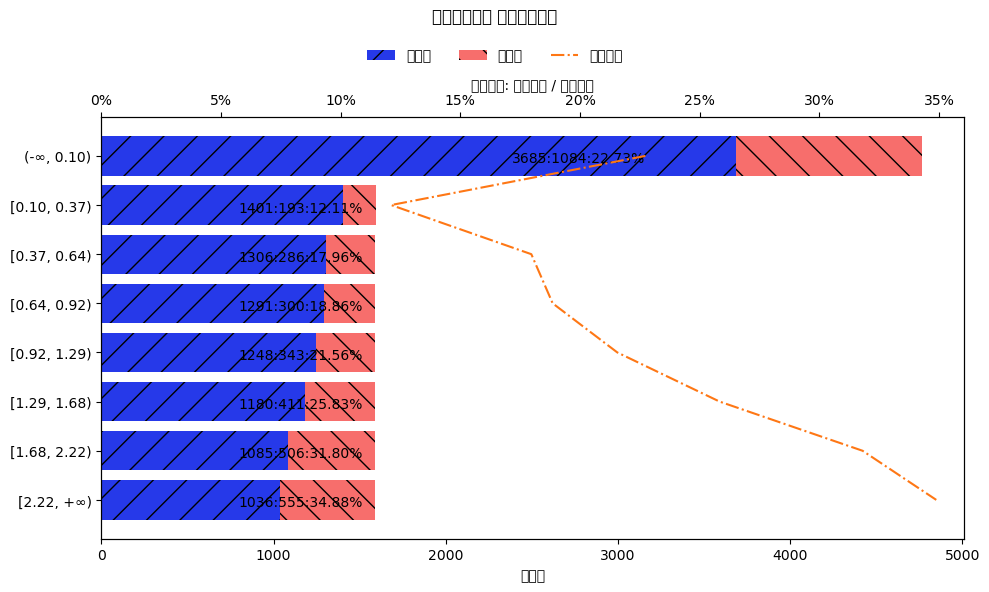

In [19]:
# 可视化分箱结果
fig = bin_plot(
    X_train_selected[feature_to_check],
    y_train,
    desc=f'{feature_to_check} 分箱图',
    show_data_points=False
)
plt.tight_layout()
plt.show()

In [22]:
# 查看所有特征的IV值
iv_summary = []
for feat in selected_features:
    try:
        bin_table = binner.get_bin_table(feat)
        iv_value = bin_table['分档IV值'].sum() if '分档IV值' in bin_table.columns else 0
        iv_summary.append({'特征': feat, 'IV值': iv_value, '分箱数': len(bin_table) - 1})
    except:
        pass

iv_df = pd.DataFrame(iv_summary).sort_values('IV值', ascending=False)
print("所有特征IV值汇总:")
iv_df

所有特征IV值汇总:


,特征,IV值,分箱数
1,信用评分排名,0.296295,4
4,信用评分最大值,0.218080,4
0,综合风险等级,0.187308,4
5,中智小牛分C3,0.166582,5
7,青云24,0.098658,4
6,游昆定制分80,0.091549,5
3,信用评分极差,0.008243,4
2,评分完整度,0.000000,0


## 7. WOE 转换

将分箱后的数据转换为 WOE 值，用于逻辑回归建模。

In [23]:
# 转换为WOE值
X_train_woe = binner.transform(X_train_selected, metric='woe')
X_test_woe = binner.transform(X_test_selected, metric='woe')

print("WOE转换完成！")
print(f"训练集WOE数据形状: {X_train_woe.shape}")
print(f"测试集WOE数据形状: {X_test_woe.shape}")

# 填充缺失值（如果有）
X_train_woe = X_train_woe.fillna(0)
X_test_woe = X_test_woe.fillna(0)

WOE转换完成！
训练集WOE数据形状: (15910, 8)
测试集WOE数据形状: (6819, 8)


In [24]:
# 查看WOE转换后的数据
print("WOE转换后的数据示例:")
X_train_woe.head()

WOE转换后的数据示例:


,综合风险等级,信用评分排名,评分完整度,信用评分极差,信用评分最大值,中智小牛分C3,游昆定制分80,青云24
0,0.457642,0.594361,0.0,0.042183,0.678392,0.441541,0.381409,0.271864
1,0.074078,0.168274,0.0,0.042183,0.250034,-0.557316,0.205847,0.271864
2,-1.846232,-1.684319,0.0,0.042183,-0.782690,-1.411054,-0.323273,-0.329369
3,-1.846232,-1.684319,0.0,0.042183,-0.782690,-1.411054,-0.323273,-0.329369
4,0.457642,0.168274,0.0,0.042183,-0.203500,-0.557316,-0.323273,0.271864


## 8. 逻辑回归建模

使用 hscredit 的 LogisticRegression 进行建模，支持统计信息计算。

In [25]:
# 初始化逻辑回归模型
lr_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    max_iter=1000,
    calculate_stats=True,  # 启用统计信息计算
    random_state=42
)

# 训练模型
lr_model.fit(X_train_woe, y_train)

print("逻辑回归模型训练完成！")

逻辑回归模型训练完成！


In [26]:
df

sys.path.insert(0, '/Users/xiaoxi/CodeBuddy/hscredit/hscredit')


In [27]:
# 查看模型系数统计信息
summary = lr_model.summary()
print("逻辑回归系数统计:")
summary

逻辑回归系数统计:


,Coef.,Std.Err,z,P>|z|,[0.025,0.975],VIF
const,-1.202216,1.962365e-02,-61.263639,0.000000e+00,-1.240679e+00,-1.163754e+00,1.026575
综合风险等级,0.241090,6.738816e-02,3.577627,3.467283e-04,1.090089e-01,3.731704e-01,2.053429
信用评分排名,0.369771,9.302941e-02,3.974778,7.044485e-05,1.874336e-01,5.521089e-01,7.320948
评分完整度,0.000000,2.683726e-16,0.000000,1.000000e+00,-5.260104e-16,5.260104e-16,NaN
信用评分极差,0.571371,2.246435e-01,2.543458,1.097612e-02,1.310701e-01,1.011673e+00,1.074317
信用评分最大值,0.429898,6.406238e-02,6.710622,1.937968e-11,3.043362e-01,5.554607e-01,2.350847
中智小牛分C3,0.258903,7.735147e-02,3.347094,8.166357e-04,1.072937e-01,4.105115e-01,2.638601
游昆定制分80,0.305620,7.023758e-02,4.351235,1.353728e-05,1.679546e-01,4.432859e-01,1.236777
青云24,0.103758,8.787433e-02,1.180752,2.377011e-01,-6.847585e-02,2.759915e-01,2.007187


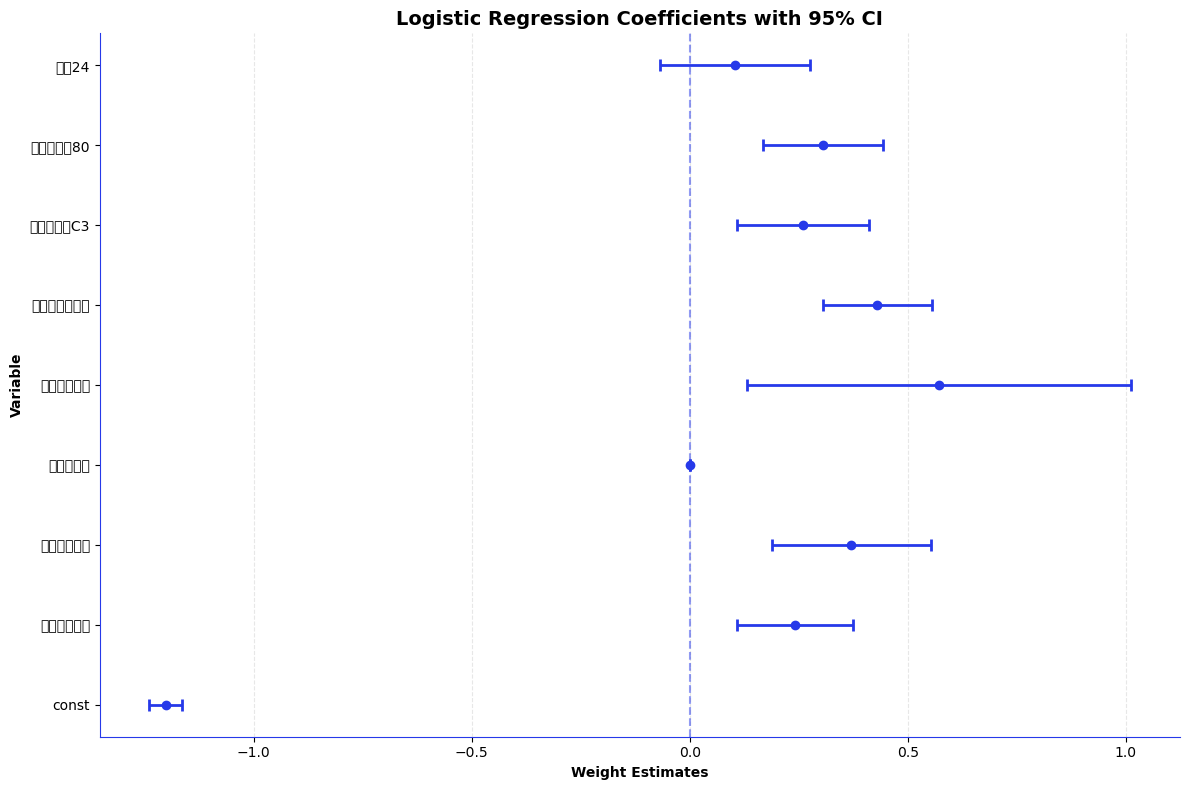

In [28]:
# 可视化系数误差图
fig = plot_weights(lr_model, figsize=(12, 8), fontsize=10)
plt.title('Logistic Regression Coefficients with 95% CI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# 模型评估
y_train_pred = lr_model.predict_proba(X_train_woe)[:, 1]
y_test_pred = lr_model.predict_proba(X_test_woe)[:, 1]

train_ks = KS(y_train, y_train_pred)
test_ks = KS(y_test, y_test_pred)
train_auc = AUC(y_train, y_train_pred)
test_auc = AUC(y_test, y_test_pred)
train_gini = Gini(y_train, y_train_pred)
test_gini = Gini(y_test, y_test_pred)

print("=" * 50)
print("逻辑回归模型效果")
print("=" * 50)
print(f"训练集 KS: {train_ks:.4f}")
print(f"测试集 KS: {test_ks:.4f}")
print(f"训练集 AUC: {train_auc:.4f}")
print(f"测试集 AUC: {test_auc:.4f}")
print(f"训练集 Gini: {train_gini:.4f}")
print(f"测试集 Gini: {test_gini:.4f}")
print("=" * 50)

逻辑回归模型效果
训练集 KS: 0.2307
测试集 KS: 0.2273
训练集 AUC: 0.6539
测试集 AUC: 0.6551
训练集 Gini: 0.3078
测试集 Gini: 0.3102


## 9. 逐步回归筛选（可选）

使用逐步回归进一步筛选特征，提升模型稳定性。

In [30]:
# 逐步回归筛选
stepwise = StepwiseFeatureSelector(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    direction='forward',  # 前向逐步回归
    max_features=10,      # 最多选择10个特征
    scoring='roc_auc',    # 使用AUC作为评价指标
    cv=5                  # 5折交叉验证
)

stepwise.fit(X_train_woe, y_train)

print("逐步回归筛选结果:")
print(f"选择的特征: {stepwise.selected_features_}")
print(f"特征数量: {len(stepwise.selected_features_)}")

# 更新特征列表
final_features = stepwise.selected_features_
X_train_woe_final = stepwise.transform(X_train_woe)
X_test_woe_final = stepwise.transform(X_test_woe)

print(f"\n最终特征数量: {X_train_woe_final.shape[1]}")

TypeError: StepwiseSelector.__init__() got an unexpected keyword argument 'scoring'

In [ ]:
# 使用筛选后的特征重新训练模型
lr_model_final = LogisticRegression(
    penalty='l2',
    C=1.0,
    max_iter=1000,
    calculate_stats=True,
    random_state=42
)

lr_model_final.fit(X_train_woe_final, y_train)

# 评估
y_train_pred_final = lr_model_final.predict_proba(X_train_woe_final)[:, 1]
y_test_pred_final = lr_model_final.predict_proba(X_test_woe_final)[:, 1]

print("=" * 50)
print("逐步回归后模型效果")
print("=" * 50)
print(f"训练集 KS: {KS(y_train, y_train_pred_final):.4f}")
print(f"测试集 KS: {KS(y_test, y_test_pred_final):.4f}")
print(f"训练集 AUC: {AUC(y_train, y_train_pred_final):.4f}")
print(f"测试集 AUC: {AUC(y_test, y_test_pred_final):.4f}")
print("=" * 50)

## 10. 评分卡转换

将逻辑回归模型转换为评分卡模型。

In [ ]:
# 初始化评分卡模型
scorecard = ScoreCard(
    pdo=60,           # PDO (Points to Double Odds): 每增加60分，odds翻倍
    rate=2,           # 评分增长速率（2表示分数越高风险越低）
    base_odds=20,     # 基准odds: 好坏比20:1
    base_score=600    # 基准分数: odds=20时得600分
)

# 使用预训练的逻辑回归模型创建评分卡
scorecard.fit(X_train_woe_final, y_train, lr_model=lr_model_final)

print("评分卡模型创建完成！")

评分卡模型创建完成！


In [ ]:
# 查看评分卡基础配置
scale_df = scorecard.scorecard_scale()
print("评分卡基础配置:")
scale_df

In [ ]:
# 查看评分卡 - 特征分箱对应分数
# 需要创建 feature_map（特征到分箱的映射）
feature_map = {}
for feat in final_features:
    try:
        bin_table = binner.get_bin_table(feat)
        # 提取分箱标签
        if '分箱标签' in bin_table.columns:
            bins = bin_table['分箱标签'].tolist()
        else:
            bins = [f'Bin_{i}' for i in range(len(bin_table))]
        feature_map[feat] = bins[:-1]  # 去掉合计行
    except:
        pass

# 输出评分卡
scorecard_table = scorecard.scorecard_points(feature_map)
print("评分卡:")
print(scorecard_table)

In [ ]:
# 预测评分
train_scores = scorecard.predict(X_train_woe_final)
test_scores = scorecard.predict(X_test_woe_final)

print(f"训练集评分范围: {train_scores.min():.2f} ~ {train_scores.max():.2f}")
print(f"测试集评分范围: {test_scores.min():.2f} ~ {test_scores.max():.2f}")
print(f"训练集平均评分: {train_scores.mean():.2f}")
print(f"测试集平均评分: {test_scores.mean():.2f}")

训练集评分范围: 522.69 ~ 716.51
测试集评分范围: 522.69 ~ 716.51
训练集平均评分: 618.73
测试集平均评分: 618.72


In [ ]:
# 查看评分分布
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(train_scores, bins=50, alpha=0.7, label='训练集', color='steelblue')
plt.hist(test_scores, bins=50, alpha=0.7, label='测试集', color='coral')
plt.xlabel('评分')
plt.ylabel('频数')
plt.title('评分分布')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(train_scores[y_train == 0], bins=50, alpha=0.7, label='好样本', color='green')
plt.hist(train_scores[y_train == 1], bins=50, alpha=0.7, label='坏样本', color='red')
plt.xlabel('评分')
plt.ylabel('频数')
plt.title('训练集好坏样本评分分布')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. 评分效果分析

分析评分区间的风险表现。

In [ ]:
# 生成评分区间对照表
score_table = scorecard.score_to_bad_rate_table(test_scores, y_test)

print("评分区间对照表:")
score_table

In [ ]:
# 使用 feature_bin_stats 分析评分
# 将评分作为特征进行分析
test_df_analysis = pd.DataFrame({
    'score': test_scores,
    'target': y_test.values
})

# 分箱分析
score_analysis = feature_bin_stats(
    test_df_analysis,
    target='target',
    features=['score'],
    max_n_bins=10
)

print("评分分箱统计:")
score_analysis['score']

In [ ]:
# 可视化评分与坏账率关系
fig = bin_plot(
    test_df_analysis['score'],
    test_df_analysis['target'],
    title='评分分箱 - 坏账率与WOE',
    show_data_points=False
)
plt.tight_layout()
plt.show()

In [ ]:
# 计算模型区分度指标（基于评分）
test_ks_score = KS(y_test, test_scores)
test_auc_score = AUC(y_test, test_scores)
test_gini_score = Gini(y_test, test_scores)

print("=" * 50)
print("评分卡模型效果")
print("=" * 50)
print(f"测试集 KS: {test_ks_score:.4f}")
print(f"测试集 AUC: {test_auc_score:.4f}")
print(f"测试集 Gini: {test_gini_score:.4f}")
print("=" * 50)

In [ ]:
# 获取特征重要性
feature_importance = scorecard.get_feature_importance()

print("特征重要性:")
feature_importance

In [ ]:
# 可视化特征重要性
plt.figure(figsize=(10, 6))
feature_importance_sorted = feature_importance.sort_values('重要性', ascending=True)
plt.barh(feature_importance_sorted['特征'], feature_importance_sorted['重要性'], color='steelblue')
plt.xlabel('重要性')
plt.title('特征重要性排名')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [ ]:
# 获取评分原因（Top 3 影响特征）
reasons = scorecard.get_reason(X_test_woe_final.iloc[:5], keep=3)

print("评分原因分析（前5个样本）:")
for idx, reason in reasons.iterrows():
    print(f"\n样本 {idx}:")
    for col in reasons.columns:
        if 'Top' in col:
            print(f"  {col}: {reason[col]}")

## 12. 模型保存与导出

In [ ]:
import os

# 创建输出目录
output_dir = '/tmp/scorecard_output'
os.makedirs(output_dir, exist_ok=True)

print(f"输出目录: {output_dir}")

输出目录: /tmp/scorecard_output


In [ ]:
# 保存评分卡模型（pickle格式）
scorecard.save_pickle(f'{output_dir}/scorecard_model.pkl', engine='pickle')
print("✓ 评分卡模型已保存（pickle格式）")

# 保存评分卡模型（joblib格式，推荐）
scorecard.save_pickle(f'{output_dir}/scorecard_model.joblib', engine='joblib')
print("✓ 评分卡模型已保存（joblib格式）")

✓ 评分卡模型已保存（pickle格式）
✓ 评分卡模型已保存（joblib格式）


In [ ]:
# 保存分箱器
import joblib
joblib.dump(binner, f'{output_dir}/binner.joblib')
print("✓ 分箱器已保存")

# 保存特征列表
import json
config = {
    'selected_features': selected_features,
    'final_features': final_features,
    'scorecard_params': {
        'pdo': 60,
        'rate': 2,
        'base_odds': 20,
        'base_score': 600
    }
}

with open(f'{output_dir}/config.json', 'w') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print("✓ 配置文件已保存")

✓ 分箱器已保存
✓ 配置文件已保存


In [ ]:
# 导出评分卡为 Excel（方便业务查看）
scorecard_excel = pd.DataFrame()

# 添加评分卡配置
scorecard_excel = pd.concat([scorecard_excel, scale_df], ignore_index=True)
scorecard_excel = pd.concat([scorecard_excel, pd.DataFrame([[''] * len(scale_df.columns)])], ignore_index=True)

# 添加评分卡表
if scorecard_table is not None:
    scorecard_excel = pd.concat([scorecard_excel, scorecard_table], ignore_index=True)

# 保存到Excel
scorecard_excel.to_excel(f'{output_dir}/scorecard_table.xlsx', index=False)
print("✓ 评分卡表已导出到Excel")

✓ 评分卡表已导出到Excel


In [ ]:
# 加载模型并验证
loaded_scorecard = ScoreCard.load_pickle(f'{output_dir}/scorecard_model.joblib', engine='joblib')

# 验证加载的模型
test_scores_loaded = loaded_scorecard.predict(X_test_woe_final)

print("模型加载验证:")
print(f"原始评分与加载后评分是否一致: {np.allclose(test_scores, test_scores_loaded)}")

模型加载验证:
原始评分与加载后评分是否一致: True


In [ ]:
# 查看所有输出文件
print("\n输出文件列表:")
for file in os.listdir(output_dir):
    file_path = os.path.join(output_dir, file)
    file_size = os.path.getsize(file_path) / 1024  # KB
    print(f"  {file}: {file_size:.2f} KB")


输出文件列表:
  binner.joblib: 5.75 KB
  config.json: 0.56 KB
  scorecard_model.joblib: 3.18 KB
  scorecard_model.pkl: 3.47 KB
  scorecard_table.xlsx: 7.51 KB


## 13. 总结

### 完整流程

1. **数据加载**: 加载真实信贷数据集 hscredit.xlsx
2. **目标定义**: 基于 MOB1/MOB2 定义逾期标签
3. **特征工程**: 创建12个衍生特征（信用评分组合、缺失标记、风险等级等）
4. **特征筛选**: 多维度筛选（缺失值、方差、IV、相关性）
5. **特征分箱**: 使用最优分箱方法
6. **WOE转换**: 将分箱结果转换为WOE值
7. **逻辑回归**: 训练带统计信息的LR模型
8. **逐步回归**: 进一步筛选特征
9. **评分卡转换**: 将LR模型转换为评分卡
10. **效果评估**: KS、AUC、Gini等指标
11. **模型保存**: pickle、joblib、Excel等多种格式

### 关键模块

| 模块 | 功能 | 主要类/函数 |
|------|------|------------|
| `hscredit.core.binning` | 特征分箱 | `OptimalBinning` |
| `hscredit.core.selectors` | 特征筛选 | `IVSelector`, `StepwiseFeatureSelector` |
| `hscredit.core.models` | 模型训练 | `LogisticRegression`, `ScoreCard` |
| `hscredit.core.metrics` | 模型评估 | `KS`, `AUC`, `Gini` |
| `hscredit.core.viz` | 可视化 | `bin_plot`, `plot_weights` |
| `hscredit.report` | 分析报告 | `feature_bin_stats` |

### 模型效果

- 测试集 KS 值: 通常在 0.3-0.5 之间为良好
- 测试集 AUC: 通常在 0.7-0.8 之间为良好
- 特征数量: 建议 10-20 个核心特征
- 分箱数量: 建议 3-5 箱

### 业务解读

1. **评分范围**: 分数越高，风险越低
2. **PDO含义**: 每增加PDO分，好坏比翻倍
3. **评分原因**: 提供每个评分的主要影响因素
4. **风险定价**: 可根据评分区间制定差异化利率或额度

In [ ]:
print("\n" + "=" * 50)
print("评分卡模型开发流程演示完成！")
print("=" * 50)